# 02. Przygotowanie i analiza danych

**Etap z planu pracy:** przygotowanie i analiza danych.

Notebook sprawdza, czy przygotowane cechy wystarczaja do testowania H1-H3, oraz wykonuje podstawowa eksploracje statystyczna i wizualizacje.


In [1]:
from pathlib import Path
import json
import sys

import numpy as np
import pandas as pd
from IPython.display import Markdown, display

PROJECT_ROOT = Path.cwd()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "database").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

DATA_PATH = PROJECT_ROOT / "database" / "NajnowszaWersjaBazy1205_prepared.csv"
RAW_DATA_PATH = PROJECT_ROOT / "database" / "NajnowszaWersjaBazy1205.csv"
METADATA_PATH = PROJECT_ROOT / "outputs" / "prepared_dataset_metadata.json"
OUTPUT_DIR = PROJECT_ROOT / "outputs" / "czysta_baza"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", lambda value: f"{value:.4f}")

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_PATH:", DATA_PATH)
print("Prepared data exists:", DATA_PATH.exists())
print("Output dir:", OUTPUT_DIR)

assert DATA_PATH.exists(), f"Brakuje pliku z przygotowana baza: {DATA_PATH}"


PROJECT_ROOT: C:\Users\szymon\projekt_reddit
DATA_PATH: C:\Users\szymon\projekt_reddit\database\NajnowszaWersjaBazy1205_prepared.csv
Prepared data exists: True
Output dir: C:\Users\szymon\projekt_reddit\outputs\czysta_baza


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

with open(METADATA_PATH, "r", encoding="utf-8") as file:
    metadata = json.load(file)

df = pd.read_csv(DATA_PATH, parse_dates=["TIMESTAMP"])
numeric_features = [column for column in metadata["numeric_features"] if column in df.columns]
cognitive_features = [column for column in metadata["cognitive_complexity_features"] if column in df.columns]
structural_features = [column for column in metadata["structural_features"] if column in df.columns]

feature_inventory = pd.DataFrame([
    {"group": "numeric_features", "available_columns": len(numeric_features)},
    {"group": "cognitive_complexity_features", "available_columns": len(cognitive_features)},
    {"group": "structural_features", "available_columns": len(structural_features)},
    {"group": "indicator_features", "available_columns": len([column for column in metadata["indicator_features"] if column in df.columns])},
    {"group": "text_features", "available_columns": len([column for column in metadata["text_features"] if column in df.columns])},
])
display(feature_inventory)
feature_inventory.to_csv(OUTPUT_DIR / "02_feature_inventory.csv", index=False)


,group,available_columns
0,numeric_features,94
1,cognitive_complexity_features,6
2,structural_features,7
3,indicator_features,1
4,text_features,3


,is_negative_link,rows,share
0,0,46064,0.9228
1,1,3854,0.0772


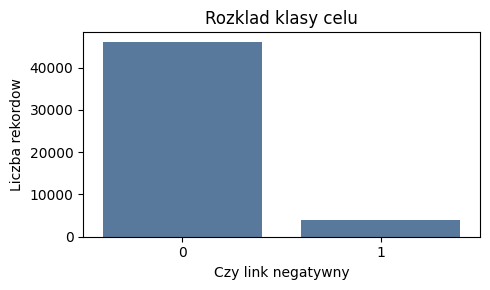

In [3]:
target_distribution = (
    df["is_negative_link"]
    .value_counts()
    .sort_index()
    .rename_axis("is_negative_link")
    .reset_index(name="rows")
)
target_distribution["share"] = target_distribution["rows"] / target_distribution["rows"].sum()
display(target_distribution)
target_distribution.to_csv(OUTPUT_DIR / "02_target_distribution.csv", index=False)

fig, ax = plt.subplots(figsize=(5, 3))
sns.barplot(data=target_distribution, x="is_negative_link", y="rows", ax=ax, color="#4c78a8")
ax.set_title("Rozklad klasy celu")
ax.set_xlabel("Czy link negatywny")
ax.set_ylabel("Liczba rekordow")
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "02_target_distribution.png", dpi=160)


,TIMESTAMP,rows,negative_links,negative_rate
29,2016-05-31,0,0,NaN
30,2016-06-30,0,0,NaN
31,2016-07-31,1,0,0.0000
32,2016-08-31,0,0,NaN
33,2016-09-30,2,0,0.0000
34,2016-10-31,0,0,NaN
35,2016-11-30,0,0,NaN
36,2016-12-31,2,0,0.0000
37,2017-01-31,1,0,0.0000
38,2017-02-28,0,0,NaN


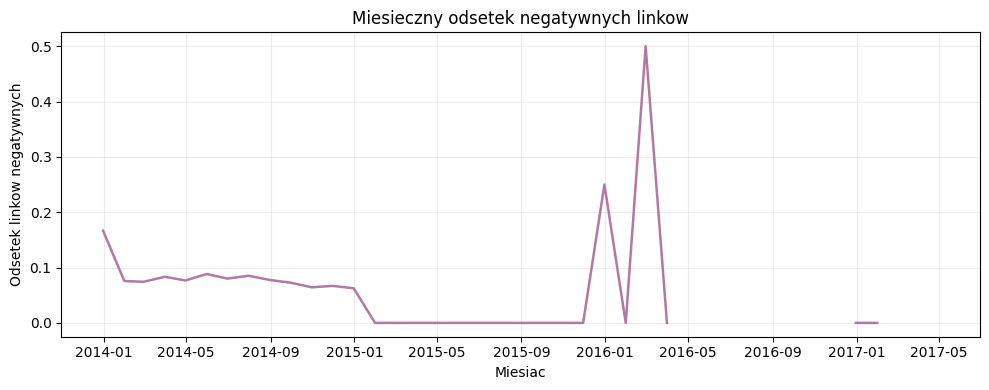

In [4]:
monthly = (
    df.set_index("TIMESTAMP")
    .resample("ME")["is_negative_link"]
    .agg(rows="size", negative_links="sum", negative_rate="mean")
    .reset_index()
)
display(monthly.tail(12))
monthly.to_csv(OUTPUT_DIR / "02_monthly_negative_rate.csv", index=False)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(monthly["TIMESTAMP"], monthly["negative_rate"], color="#b279a2", linewidth=1.8)
ax.set_title("Miesieczny odsetek negatywnych linkow")
ax.set_xlabel("Miesiac")
ax.set_ylabel("Odsetek linkow negatywnych")
ax.grid(True, alpha=0.25)
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "02_monthly_negative_rate.png", dpi=160)


In [5]:
top_pairs = (
    df.groupby(["SOURCE_SUBREDDIT", "TARGET_SUBREDDIT"])
    .agg(rows=("POST_ID", "size"), negative_links=("is_negative_link", "sum"), negative_rate=("is_negative_link", "mean"))
    .sort_values(["rows", "negative_links"], ascending=False)
    .head(20)
    .reset_index()
)
display(top_pairs)
top_pairs.to_csv(OUTPUT_DIR / "02_top_directed_pairs.csv", index=False)


,SOURCE_SUBREDDIT,TARGET_SUBREDDIT,rows,negative_links,negative_rate
0,trendingsubreddits,changelog,110,0,0.0000
1,crashwhowritings,writingprompts,108,0,0.0000
2,buildapc,buildapcforme,70,0,0.0000
3,eatcheapandhealthy,freeebooks,69,0,0.0000
4,magicthecirclejerking,magictcg,67,6,0.0896
5,hailcorporate,funny,63,1,0.0159
6,circlebroke,askreddit,62,18,0.2903
7,hailcorporate,pics,62,3,0.0484
8,brokehugs,christianity,61,17,0.2787
9,circloljerk,leagueoflegends,61,11,0.1803


In [6]:
eda_features = [
    "LIWC_Anger",
    "prev_pair_interactions_24h",
    "prev_pair_mean_anger_24h",
    "Average word length",
    "LIWC_Conj",
    "Automated readability index",
    "LIWC_CogMech",
    "Number of words",
    "common_neighbors_so_far",
]
eda_features = [column for column in eda_features if column in df.columns]

description = df[eda_features].describe().T
display(description)
description.to_csv(OUTPUT_DIR / "02_feature_descriptions.csv")


,count,mean,std,min,25%,50%,75%,max
LIWC_Anger,49918.0000,0.0049,0.0103,0.0000,0.0000,0.0000,0.0059,0.2459
prev_pair_interactions_24h,49918.0000,0.0119,0.1314,0.0000,0.0000,0.0000,0.0000,6.0000
prev_pair_mean_anger_24h,49918.0000,0.0001,0.0010,0.0000,0.0000,0.0000,0.0000,0.0708
Average word length,49918.0000,5.3325,1.4129,1.9251,4.5589,4.9543,5.6562,175.9500
LIWC_Conj,49918.0000,0.0408,0.0281,0.0000,0.0187,0.0435,0.0614,0.2678
Automated readability index,49918.0000,21.4808,15.4829,5.5383,15.1101,18.5571,24.2982,822.7110
LIWC_CogMech,49918.0000,0.1167,0.0627,0.0000,0.0750,0.1253,0.1617,0.3636
Number of words,49918.0000,232.3304,354.1721,9.0000,42.0000,107.0000,263.0000,7094.0000
common_neighbors_so_far,49918.0000,4.3114,11.1509,0.0000,0.0000,1.0000,3.0000,245.0000


## Rezultat etapu

Dane sa gotowe do modelowania, ale wymagaja metryk odpornych na niezbalansowanie klas. Analizy H1 i H2 powinny raportowac rozmiary grup oraz testy istotnosci, a H3 musi oceniac przede wszystkim F1/precision/recall klasy negatywnej.
